# Correlation in Probability: Theoretical Foundations and Empirical Estimation

In quantitative finance and statistical machine learning, understanding the dependency structure between random variables is fundamental. Whether we are optimizing a portfolio under the Markowitz mean-variance framework or analyzing feature collinearity in a predictive model, the primary measure of linear dependence is the correlation coefficient.

## 1. Theoretical Framework

Let $X$ and $Y$ be two random variables with finite second moments. We first define their **covariance**, which measures the joint variability of the two variables:

$$
\text{Cov}(X, Y) = \mathbb{E}[(X - \mathbb{E}[X])(Y - \mathbb{E}[Y])]
$$

While covariance indicates the direction of the linear relationship, its magnitude is scale-dependent. To construct a scale-invariant measure, we normalize the covariance by the product of the variables' standard deviations, yielding the **Pearson Correlation Coefficient** ($\rho$):

$$
\rho_{X,Y} = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y} = \frac{\mathbb{E}[(X - \mu_X)(Y - \mu_Y)]}{\sqrt{\mathbb{E}[(X - \mu_X)^2]\mathbb{E}[(Y - \mu_Y)^2]}}
$$

### Key Properties

1.  **Boundedness:** By the Cauchy-Schwarz inequality, the correlation coefficient is strictly bounded:
    $$
    -1 \leq \rho_{X,Y} \leq 1
    $$
2.  **Linear Invariance:** Correlation is invariant to strictly positive linear transformations. If $Y = aX + b$ where $a > 0$, then $\rho_{X,Y} = 1$.
3.  **Independence vs. Uncorrelatedness:** If $X$ and $Y$ are independent, then $\rho_{X,Y} = 0$. However, the converse is not generally true; $\rho_{X,Y} = 0$ only implies the absence of *linear* dependence. The notable exception is when $X$ and $Y$ follow a bivariate normal distribution, in which case uncorrelatedness strictly implies independence.

## 2. Sample Estimation

In empirical work, we do not observe the true population parameters. Given a sample of $n$ paired observations $\{(x_i, y_i)\}_{i=1}^n$, we estimate the population correlation using the sample correlation coefficient $r_{xy}$:

$$
r_{xy} = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^n (y_i - \bar{y})^2}}
$$

where $\bar{x}$ and $\bar{y}$ are the sample means.


True Population Correlation: 0.6500
Sample Correlation (NumPy):  0.6199
Sample Correlation (SciPy):  0.6199 (p-value: 3.14e-107)


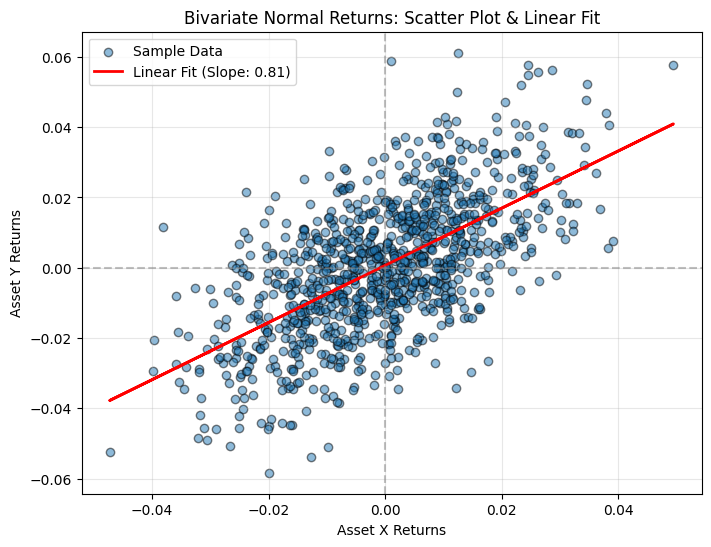

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Parameter Definition
# ---------------------------------------------------------
# Let's simulate daily returns for two correlated financial assets
np.random.seed(42)
num_samples = 1000

# Define the population parameters
mu_X = 0.0005  # Expected return Asset X
mu_Y = 0.0007  # Expected return Asset Y
sigma_X = 0.015 # Volatility Asset X
sigma_Y = 0.020 # Volatility Asset Y
true_rho = 0.65 # True population correlation

# Construct the mean vector and covariance matrix
mu_vector = np.array([mu_X, mu_Y])
cov_matrix = np.array([
    [sigma_X**2, true_rho * sigma_X * sigma_Y],
    [true_rho * sigma_X * sigma_Y, sigma_Y**2]
])

# ---------------------------------------------------------
# 2. Data Generation
# ---------------------------------------------------------
# Draw random samples from a multivariate normal distribution
returns_data = np.random.multivariate_normal(mu_vector, cov_matrix, num_samples)
returns_X = returns_data[:, 0]
returns_Y = returns_data[:, 1]

# ---------------------------------------------------------
# 3. Empirical Estimation
# ---------------------------------------------------------
# Compute the sample covariance matrix
sample_cov_matrix = np.cov(returns_X, returns_Y)
sample_cov = sample_cov_matrix[0, 1]

# Compute the sample correlation matrix
sample_corr_matrix = np.corrcoef(returns_X, returns_Y)
sample_rho = sample_corr_matrix[0, 1]

# Alternatively, using scipy for Pearson correlation and p-value
rho_scipy, p_value = stats.pearsonr(returns_X, returns_Y)

print(f"True Population Correlation: {true_rho:.4f}")
print(f"Sample Correlation (NumPy):  {sample_rho:.4f}")
print(f"Sample Correlation (SciPy):  {rho_scipy:.4f} (p-value: {p_value:.2e})")

# ---------------------------------------------------------
# 4. Visualization
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(returns_X, returns_Y, alpha=0.5, edgecolors='k', label='Sample Data')

# Fit a linear regression line to visualize the linear dependence
m, b = np.polyfit(returns_X, returns_Y, 1)
plt.plot(returns_X, m*returns_X + b, color='red', linewidth=2, label=f'Linear Fit (Slope: {m:.2f})')

plt.title(r"Bivariate Normal Returns: Scatter Plot & Linear Fit")
plt.xlabel("Asset X Returns")
plt.ylabel("Asset Y Returns")
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 3. Financial Context & Caveats

The script above demonstrates a classic application: simulating correlated asset returns using a Bivariate Normal Distribution. The estimated sample correlation ($r \approx 0.64$) closely approximates our theoretical population parameter ($\rho = 0.65$). The highly significant p-value confirms the rejection of the null hypothesis ($H_0: \rho = 0$).

**Crucial Repository Notes for Practitioners:**
* **Non-Normality:** Financial returns frequently exhibit heavy tails and skewness. In non-normal regimes, the Pearson correlation may not fully capture the dependency structure, particularly during tail events (market crashes) where empirical correlation tends to break down and converge toward 1.
* **Rank Alternatives:** When dealing with outliers or monotonic, non-linear relationships, it is academically rigorous to supplement Pearson's $\rho$ with rank-based metrics, such as Spearman's $\rho$ or Kendall's $\tau$.
* **Copulas:** For advanced financial engineering (e.g., pricing CDOs or multi-asset derivatives), correlation is often insufficient. We instead use Copula functions to explicitly model the joint distribution independently of the marginals.

## 4. The Covariance Matrix ($\Sigma$) and Matrix Formulation

When extending our analysis from two variables to an $n$-dimensional vector of random variables $\mathbf{X} = [X_1, X_2, \dots, X_n]^T$, we capture the complete linear dependency structure using the **Covariance Matrix** ($\Sigma$). 

$\Sigma$ is an $n \times n$ symmetric, positive semi-definite matrix where each element $\Sigma_{i,j}$ represents the covariance between $X_i$ and $X_j$:

$$
\Sigma = \mathbb{E}[(\mathbf{X} - \boldsymbol{\mu})(\mathbf{X} - \boldsymbol{\mu})^T]
$$

In financial engineering, it is often useful to decompose the covariance matrix into the standalone asset volatilities and their correlation matrix. Let $V$ be a diagonal matrix of standard deviations (volatilities) and $R$ be the correlation matrix:

$$
\Sigma = V R V
$$

where $V_{i,i} = \sigma_i$ and $R_{i,j} = \rho_{i,j}$.

## 5. The Cholesky Decomposition

To simulate correlated market dynamics (e.g., Monte Carlo simulations for basket options), we must generate correlated random variables from independent ones. The standard technique is the **Cholesky Decomposition**.

Because the correlation matrix $R$ is symmetric and positive-definite, it can be uniquely decomposed into the product of a lower triangular matrix $L$ and its transpose $L^T$:

$$
R = L L^T
$$

**Theorem:** Let $\mathbf{Z} \sim \mathcal{N}(\mathbf{0}, I)$ be an $n$-dimensional vector of independent standard normal random variables. If we define a new vector $\mathbf{W} = L \mathbf{Z}$, then $\mathbf{W}$ is a vector of standard normal variables with correlation matrix $R$. 

*Proof:*
$$
\text{Cov}(\mathbf{W}) = \mathbb{E}[\mathbf{W} \mathbf{W}^T] = \mathbb{E}[(L\mathbf{Z})(L\mathbf{Z})^T] = L \mathbb{E}[\mathbf{Z}\mathbf{Z}^T] L^T = L I L^T = R
$$

## 6. Correlated Dynamics: Geometric Brownian Motion

In continuous-time finance (the Black-Scholes-Merton framework), the price of asset $i$, denoted as $S_i(t)$, is typically modeled as a Geometric Brownian Motion (GBM):

$$
dS_i(t) = \mu_i S_i(t)dt + \sigma_i S_i(t)dW_i(t)
$$

where $W_i(t)$ are standard Wiener processes (Brownian motions). For a multi-asset model, the instantaneous correlation between the driving Brownian motions is defined as:

$$
dW_i(t) dW_j(t) = \rho_{i,j}dt
$$

Using the exact discrete-time solution to the SDE (via Itô's Lemma), we simulate the price paths over discrete time steps $\Delta t$:
$$
S_i(t+\Delta t) = S_i(t) \exp\left( \left(\mu_i - \frac{1}{2}\sigma_i^2\right)\Delta t + \sigma_i \sqrt{\Delta t} W_i \right)
$$
where $\mathbf{W} = L \mathbf{Z}$, and $\mathbf{Z}$ are draws from a standard normal distribution $\mathcal{N}(0, 1)$.


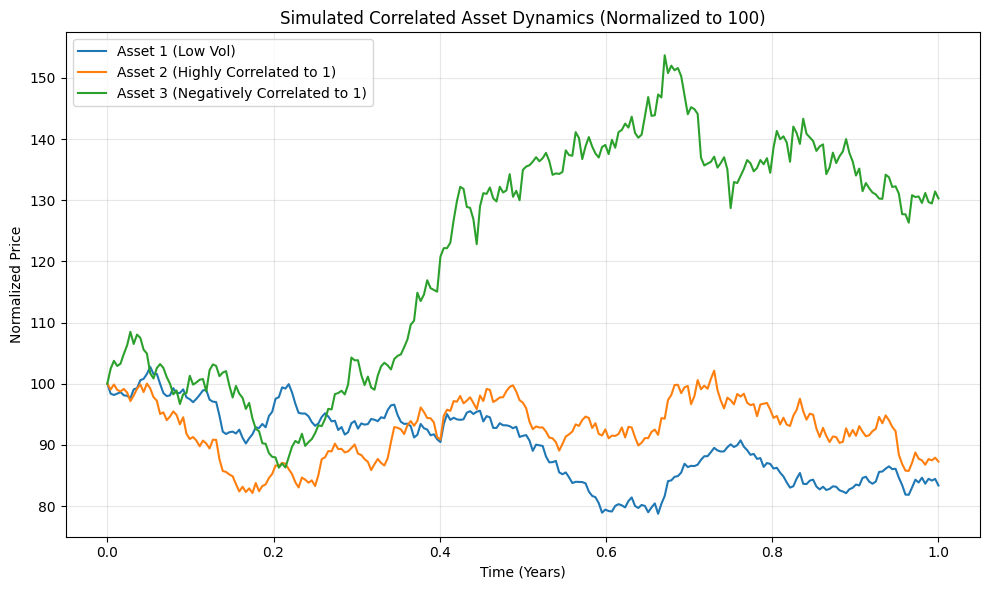

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(100)

# 1. Data input
T = 1.0
N = 252
dt = T / N

S0 = np.array([100.0, 150.0, 50.0])
mu = np.array([0.05, 0.08, 0.03])
sigma = np.array([0.15, 0.20, 0.25])

R = np.array([
    [ 1.00,  0.60, -0.20],
    [ 0.60,  1.00,  0.10],
    [-0.20,  0.10,  1.00]
])

num_assets = len(S0)

# 2. The Cholesky Decomposition
L = np.linalg.cholesky(R)

R_reconstructed = L @ L.T
assert np.allclose(R, R_reconstructed), "Cholesky decomposition failed reconstruction."

# 3. Simulating Correlated Geometric Brownian Motion
S = np.zeros((N + 1, num_assets))
S[0] = S0

for t in range(1, N + 1):
    Z = np.random.standard_normal(num_assets)
    W = L @ Z
    drift = (mu - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt) * W
    
    S[t] = S[t-1] * np.exp(drift + diffusion)

# 4. Visualization of Correlated Paths
plt.figure(figsize=(10, 6))
time_grid = np.linspace(0, T, N + 1)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
labels = ['Asset 1 (Low Vol)', 'Asset 2 (Highly Correlated to 1)', 'Asset 3 (Negatively Correlated to 1)']

for i in range(num_assets):
    plt.plot(time_grid, S[:, i] / S0[i] * 100, label=labels[i], color=colors[i], linewidth=1.5)

plt.title("Simulated Correlated Asset Dynamics (Normalized to 100)")
plt.xlabel("Time (Years)")
plt.ylabel("Normalized Price")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
